## Interface to statsmodels: state space time series models

This notebook provides a short exposition of how it is possible to interface with the cornucopia of time series models provided by the [statsmodels](https://www.statsmodels.org/stable/index.html) package. In this notebook, we illustrate how to fit the logistic ODE model, where the errors are described by state space models.

In [1]:
import pints
import pints.toy as toy
import pints.plot
import numpy as np
import matplotlib.pyplot as plt

# Fitting a local level state space model

We assume that the observed data $y(t)$ follows

$$y(t)= f(t; \theta) + \epsilon(t),$$

where $f(t; \theta)$ is the [logistic model](../toy/model-logistic.ipynb) solution. The errors are assumed to follow a local level model:

$$
\begin{align*}
&\epsilon(t) = \mu(t) + \nu(t),\\
&\mu(t) = \mu(t-1) + \eta(t),
\end{align*}
$$

as described [here](https://www.statsmodels.org/devel/generated/statsmodels.tsa.statespace.structural.UnobservedComponents.html#statsmodels.tsa.statespace.structural.UnobservedComponents) (also see this link for a description of the huge family of state space models available in this package). Here, $\nu(t) \sim \mathcal{N}(0, \sigma_\nu)$ and $\eta(t) \sim \mathcal{N}(0, \sigma_\eta)$.

The two parameters of the error process are the variances: $\sigma_\nu^2$ and $\sigma_\eta^2$.

In [2]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

We first generate some local level noise and overlay on the ODE. Note that this noise is non-stationary, so the observed data can drift away from the actual solution for long periods.

In [35]:
help(model.simulate)

Help on method simulate in module statsmodels.tsa.statespace.mlemodel:

simulate(params, nsimulations, measurement_shocks=None, state_shocks=None, initial_state=None, anchor=None, repetitions=None, exog=None, extend_model=None, extend_kwargs=None, transformed=True, includes_fixed=False, pretransformed_measurement_shocks=True, pretransformed_state_shocks=True, pretransformed_initial_state=True, random_state=None, **kwargs) method of statsmodels.tsa.statespace.structural.UnobservedComponents instance
    Simulate a new time series following the state space model
    
    Parameters
    ----------
    params : array_like
        Array of parameters to use in constructing the state space
        representation to use when simulating.
    nsimulations : int
        The number of observations to simulate. If the model is
        time-invariant this can be any number. If the model is
        time-varying, then this number must be less than or equal to the
        number of observations.
    m

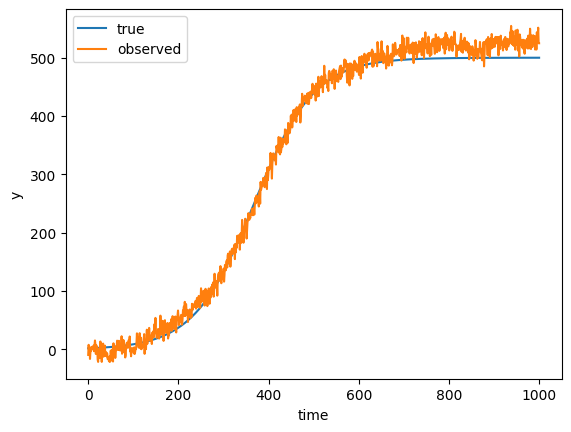

In [3]:
import scipy.stats

# Load a forward model
model = toy.LogisticModel()

# Create some toy data
real_parameters = [0.015, 500]
times = np.linspace(0, 1000, 1000)
org_values = model.simulate(real_parameters, times)

# function to generate local level errors
def local_level(n, sigma_nu, sigma_eta):
    nu = scipy.stats.norm.rvs(0, sigma_nu, n)
    eta = scipy.stats.norm.rvs(0, sigma_eta, n)
    epsilon = np.zeros(n)
    mu = np.zeros(n)
    mu[0] = eta[0]
    for i in range(1, n):
        mu[i] = mu[i - 1] + eta[i]
    for i in range(n):
        epsilon[i] = mu[i] + nu[i]
    return epsilon

sigma_nu = 10
sigma_eta = 1
errors = local_level(len(org_values), sigma_nu, sigma_eta)
values = org_values + errors

# Show the noisy data
plt.figure()
plt.plot(times, org_values)
plt.plot(times, values)
plt.xlabel('time')
plt.ylabel('y')
plt.legend(['true', 'observed'])
plt.show()

Note, that when wrapping the various models in this package into Pints, a useful function is the `model.param_names` function that provides a description of these parameters. We illustrate this below: note that `beta.x1` is the coefficient on the ODE solution, so needs to be supplied as '1' in the wrapper we show later.

In [4]:
sol = model.simulate([0.15, 500], times)
model = UnobservedComponents(endog=values, level='llevel', exog=sol)
model.param_names

['sigma2.irregular', 'sigma2.level', 'beta.x1']

Wrapping the a state space model in a Pints log-likelihood. Here, `ss_model` is a string corresponding to the list of prebuilt state space models [here](https://www.statsmodels.org/devel/generated/statsmodels.tsa.statespace.structural.UnobservedComponents.html#statsmodels.tsa.statespace.structural.UnobservedComponents); `ss_n_params` is the number of parameters that the particular time series model involves.

In [5]:
class StateSpaceLogLikelihood(pints.ProblemLogLikelihood):
    def __init__(self, problem, ss_model, ss_n_params):
        super(StateSpaceLogLikelihood, self).__init__(problem)
        self._nt = len(self._times) - 1
        self._no = problem.n_outputs()
        self._ss_model = ss_model
        self._ss_n_params = ss_n_params
        self._n_parameters = problem.n_parameters() + ss_n_params * self._no
        self._m = self._ss_n_params * self._no
        
    def __call__(self, x):
        # converting to list makes it easier to append
        # nuisance params
        x = x.tolist()
        m = self._m
        # extract noise model params
        parameters = x[-m:]
        sol = self._problem.evaluate(x[:-m])
        model = UnobservedComponents(endog=problem.values(),
                                     level=self._ss_model, exog=sol)
        
        # add nuisance parameter at end: the coefficient
        # on the ODE model solution (which should be 1)
        return model.loglike(parameters + [1])

Instantiate the model, log-posterior etc., then run MCMC.

In [6]:
model = toy.LogisticModel()

# Create an object with links to the model and time series
problem = pints.SingleOutputProblem(model, times, values)

# Create a log-likelihood function
log_likelihood = StateSpaceLogLikelihood(problem, 'llevel', 2)

# Create a uniform prior over both the parameters and the new noise variable
log_prior = pints.UniformLogPrior(
    [0.00, 400, 0, 0],
    [0.05, 600, 3000, 3000],
)

# Create a posterior log-likelihood (log(likelihood * prior))
log_posterior = pints.LogPosterior(log_likelihood, log_prior)

# Choose starting points for 3 mcmc chains
real_parameters = np.array([0.015, 500] + [sigma_nu**2, sigma_eta**2])
xs = [
    real_parameters * 1.05,
    real_parameters * 1,
    real_parameters * 1.025
]

# Create mcmc routine
mcmc = pints.MCMCController(log_posterior, 3, xs, method=pints.HaarioBardenetACMC)

# Add stopping criterion
mcmc.set_max_iterations(4000)

# Disable logging
mcmc.set_log_to_screen(False)

# Run!
print('Running...')
chains = mcmc.run()
print('Done!')

Running...
Done!


Show traces.

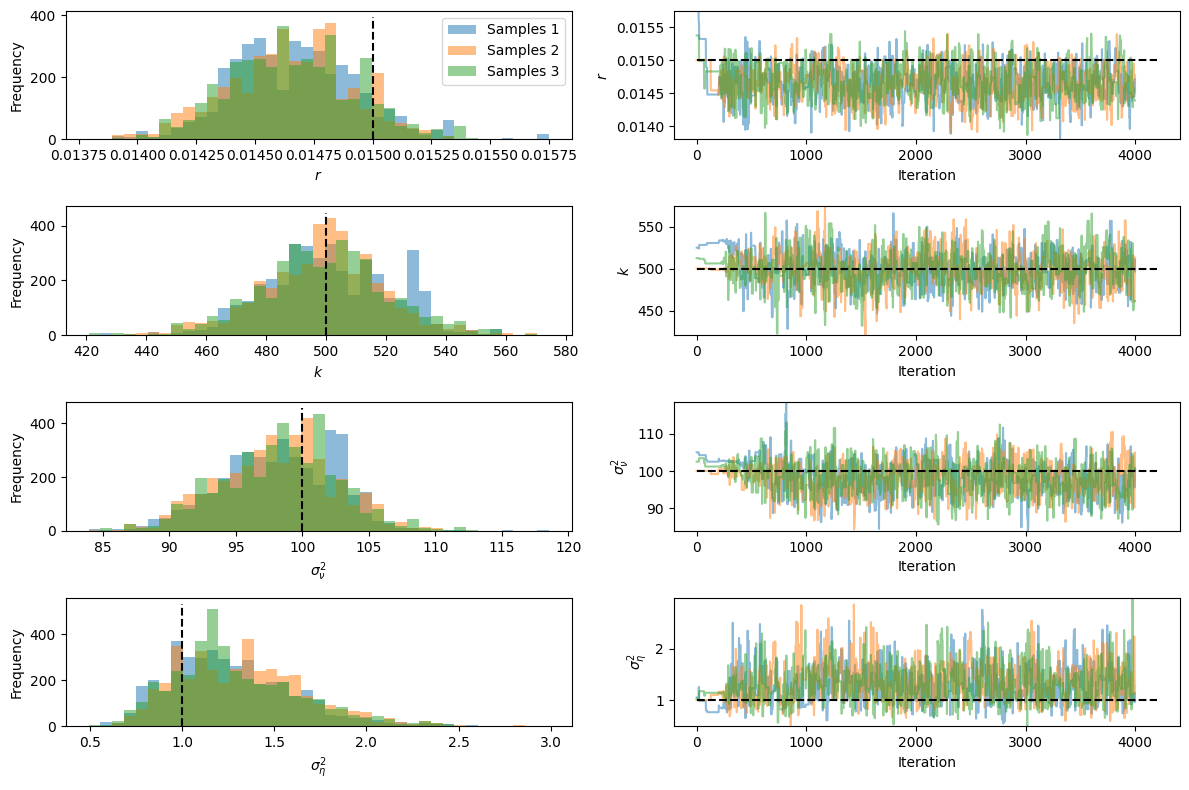

In [7]:
pints.plot.trace(chains,
                 parameter_names=[r'$r$', r'$k$', r'$\sigma^2_{\nu}$', r'$\sigma^2_{\eta}}$'],
                 ref_parameters=real_parameters)
plt.show()

Look at summary stats: all parameters look similar to their true values.

In [8]:
results = pints.MCMCSummary(chains=chains, 
                            parameter_names=["r", "k", "sigma^2_nu", "sigma^2_eta"])
print(results)

param        mean    std.    2.5%    25%     50%     75%     97.5%    rhat    ess
-----------  ------  ------  ------  ------  ------  ------  -------  ------  ------
r            0.01    0.00    0.01    0.01    0.01    0.01    0.02     1.00    551.52
k            499.75  20.71   458.01  486.90  499.98  512.99  540.11   1.01    422.35
sigma^2_nu   98.27   4.31    89.99   95.34   98.50   101.29  105.97   1.02    304.79
sigma^2_eta  1.29    0.34    0.76    1.04    1.24    1.51    2.09     1.01    475.22


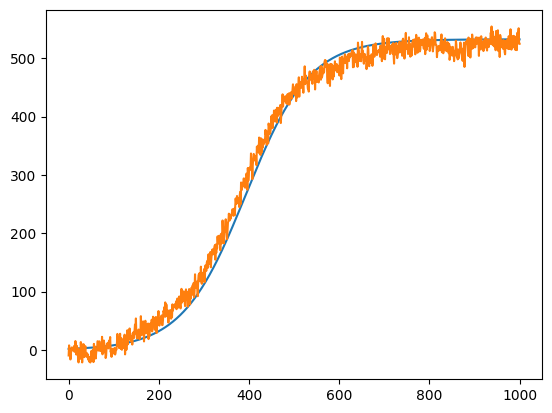

In [9]:
np.shape(chains)

sampled_p = chains[np.random.randint(0,3), np.random.randint(0, 4000), ]

my_sol = model.simulate(sampled_p[0:2], times)

plt.plot(times, my_sol)
plt.plot(times, values)
plt.show()

In [10]:
np.shape(chains)

(3, 4000, 4)

In [11]:
posterior_samples = np.reshape(chains[:, 2000:4000], (3 * 2000, 4))
post_pred = np.zeros((3 * 2000, len(times)))
post_pred_noise = np.zeros((3 * 2000, len(times)))

for i in range(3 * 2000):
    p = posterior_samples[i, 0:2]
    post_pred[i, ] = model.simulate(p, times)
    
for i in range(3 * 2000):
    post_pred_noise[i, ] = post_pred[i, ] + local_level(len(times), np.sqrt(posterior_samples[i, 2]), np.sqrt(posterior_samples[i, 3]))

array([1640,  144, 5465, 1395, 5436, 5556, 4653, 4794, 2771, 1057,  465,
       3301, 2552, 3821, 4256, 3543, 5106,    7,  647, 2327, 5687, 2059,
       5894, 3900, 3043, 5434, 4226,  875, 5375, 2715, 4346, 2788, 1515,
       4776, 5537, 5000,  421, 3931, 3712,  281, 1525, 1796,  161, 5649,
       2232, 2208, 3254,  305, 2483,  542, 5854, 2055, 5115,  939, 4950,
       4180,  380, 4886, 3719, 2498, 5616,  418, 1620,  410, 3932,  665,
        122, 4597, 2865, 4656, 2391, 1505, 5534, 5552, 2341, 1180, 5715,
       5090, 4198, 2970,   84, 3596, 3616, 1941,  954, 4081,  954, 2995,
        133, 1588,  830, 5769, 2037, 5572, 3027,   50, 3063, 3132, 3611,
        946])

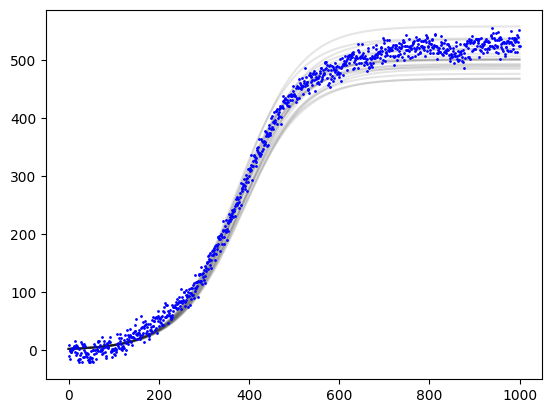

In [24]:
for i in np.random.randint(0, 3 * 2000, 20):
    plt.plot(times, post_pred[i, ], color='black', alpha=0.1)
    
plt.plot(times, values, '.', color = "blue", markersize = 2)

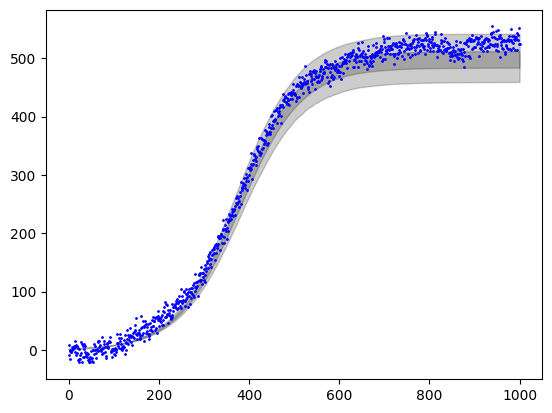

In [30]:
qs = np.quantile(post_pred, [0.025, 0.25, 0.75, 0.975], axis=0)

plt.fill_between(times, qs[0, ], qs[3, ], color = "black", alpha = 0.2)
plt.fill_between(times, qs[1, ], qs[2, ], color = "black", alpha = 0.2)
plt.plot(times, values, '.', color = "blue", markersize = 2)
plt.show()

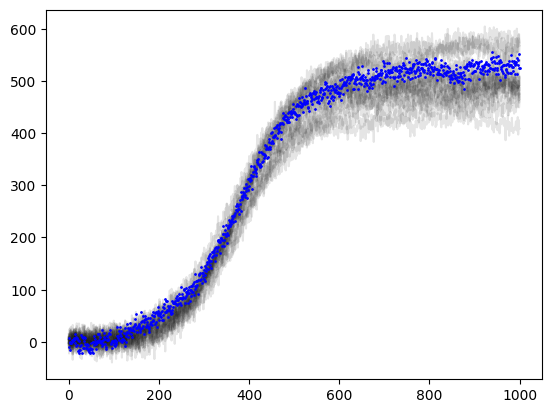

In [23]:
for i in np.random.randint(0, 3 * 2000, 20):
    plt.plot(times, post_pred_noise[i, ], color='black', alpha=0.1)
    
plt.plot(times, values, '.', color = "blue", markersize = 2)

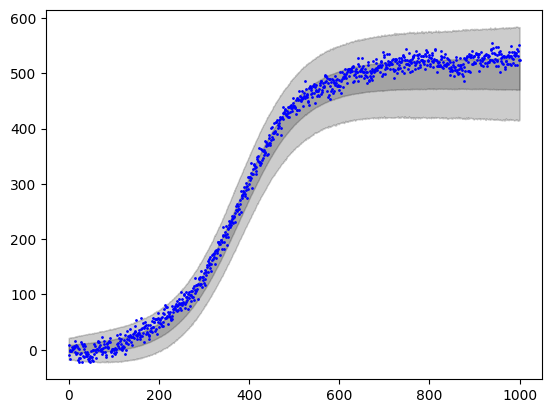

In [31]:
qs_noise = np.quantile(post_pred_noise, [0.025, 0.25, 0.75, 0.975], axis=0)

plt.fill_between(times, qs_noise[0, ], qs_noise[3, ], color = "black", alpha = 0.2)
plt.fill_between(times, qs_noise[1, ], qs_noise[2, ], color = "black", alpha = 0.2)
plt.plot(times, values, '.', color = "blue", markersize = 2)
plt.show()

In [32]:
observed_data = np.array([2, 3, 4, 3, 6])
model_pred = np.array([1, 2, 3, 3, 3])
noise = observed_data - model_pred

model = UnobservedComponents(endog = observed_data,
                             level ='llevel', 
                             exog = model_pred)

model = UnobservedComponents(endog = noise,
                             level ='llevel')
  
model.loglike(np.array([1.0, 2.0, 1.0]))

-7.4808924119216895

the same in `Julia`:

```julia
observed_data = [2.0, 3.0, 4.0, 3.0, 6.0]
model_pred = [1, 2, 3, 3, 3]
noise = observed_data .- model_pred 

my_mod = LocalLevel(noise)
fix_hyperparameters!(my_mod, Dict("sigma2_ε" => 1.0, "sigma2_η" => 2.0))
my_mod.hyperparameters.unconstrained_values = [sqrt(1.0), sqrt(2.0)]
loglike(my_mod)

# result: -7.480892411921689
```